#  House Price Prediction — XGBoost Tuning

This notebook improves the baseline XGBoost model through
cross-validation, hyperparameter tuning, and target transformation.

## Objectives

- Establish the baseline XGBoost performance
- Understand cross-validation
- Tune XGBoost hyperparameters
- Compare tuned and baseline models
- Apply logarithmic transformation to the target
- Evaluate the final candidate model
- Analyze feature importance

### Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path


from sklearn.model_selection import (
        train_test_split,
        cross_val_score,
        RandomizedSearchCV
    )

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
    )

from xgboost import XGBRegressor

In [3]:
PROJECT_ROOT=Path.cwd().parent

DATA_PATH=PROJECT_ROOT / "data" / "train.csv"

df=pd.read_csv(DATA_PATH)


df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,...,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,...,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,...,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,...,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,...,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,...,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
TARGET='SalePrice'

X=df.drop(columns=[TARGET])
y=df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 80)
y shape: (1460,)


In [5]:
numerical_features=X.select_dtypes(include=['int64','float64']).columns.tolist()

categorical_features=X.select_dtypes(include=['str']).columns.tolist()


print("Numerical:",len(numerical_features))
print("Categorical: ",len(categorical_features))

Numerical: 37
Categorical:  43


In [6]:
X_train,X_valid,y_train,y_valid=train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_valid.shape)


(1168, 80)
(292, 80)


In [7]:
numerical_pipeline=Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy='median')),
        ("scaler",StandardScaler())
    ]
)

categorical_pipeline=Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy='most_frequent')),
        ("encoder",OneHotEncoder(handle_unknown='ignore'))
    ]
)


preprocessor=ColumnTransformer(
    transformers=[
        ("num",numerical_pipeline,numerical_features),
        ("cat",categorical_pipeline,categorical_features)
    ]
)

In [8]:
baseline_xgb=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=3,random_state=42,objective="reg:squarederror"))
    ]
)

In [9]:
baseline_xgb.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

In [10]:
baseline_predictions=baseline_xgb.predict(X_valid)

In [11]:
def evaluate_model(model_name,y_true,y_pred):

    mae=mean_absolute_error(y_true,y_pred)

    rmse=np.sqrt(mean_squared_error(y_true,y_pred))

    r2=r2_score(y_true,y_pred)

    return {
        "Model":model_name,
        "MAE":mae,
        "RMSE":rmse,
        "R2":r2
    }


In [12]:
baseline_result=evaluate_model("Baseline XGBoost",y_valid,baseline_predictions)

baseline_result

{'Model': 'Baseline XGBoost',
 'MAE': 16549.45703125,
 'RMSE': np.float64(26179.08783743238),
 'R2': 0.9106498956680298}

In [13]:
cv_scores=cross_val_score(baseline_xgb,X_train,y_train,cv=5,scoring="neg_root_mean_squared_error",n_jobs=-1)

cv_rmse= -cv_scores

print("Fold RMSE scores:")
print(cv_rmse)

print("\nMean CV RMSE:", cv_rmse.mean())
print("Std CV RMSE:", cv_rmse.std())

Fold RMSE scores:
[30241.91601562 34165.40625    30678.39648438 23086.79882812
 21176.20703125]

Mean CV RMSE: 27869.744921875
Std CV RMSE: 4915.9148423250035


In [14]:
xgb_for_tuning=XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)



In [20]:
param_distributions={

        "model__n_estimators":[200,300,500,700],

        "model__learning_rate":[0.01,0.03,0.05,0.1],

        "model__max_depth":[2,3,4,5,6],

        "model__min_child_weight":[1,3,5],

        "model__subsample":[0.7,0.8,0.9,1.0],

        "model__colsample_bytree":[0.7,0.8,0.9,1.0]

    }

In [21]:
tuning_pipeline=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",xgb_for_tuning)
    ]
)

In [23]:
random_search=RandomizedSearchCV(
        estimator=tuning_pipeline,
        param_distributions=param_distributions,
        n_iter=20,
        scoring="neg_root_mean_squared_error",
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs= -1
    )

In [24]:
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a bes

In [25]:
random_search.best_params_

{'model__subsample': 0.7,
 'model__n_estimators': 700,
 'model__min_child_weight': 5,
 'model__max_depth': 4,
 'model__learning_rate': 0.1,
 'model__colsample_bytree': 0.7}

In [29]:
best_cv_rmse= -random_search.best_score_

print("Best CV RMSE: ",best_cv_rmse)

Best CV RMSE:  27684.9171875


In [30]:
tuned_xgb=random_search.best_estimator_
tuned_xgb

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

In [31]:
tuned_predictions=tuned_xgb.predict(X_valid)


tuned_predictions

array([137962.98 , 338968.   , 104468.61 , 159048.58 , 322363.   ,
        80454.09 , 224610.03 , 144903.69 ,  80902.7  , 136384.44 ,
       150113.42 , 118734.67 , 128104.4  , 203015.95 , 167438.38 ,
       126024.336, 194743.83 , 125160.28 , 118877.93 , 214943.03 ,
       151090.28 , 218308.89 , 167250.67 , 131920.14 , 195068.72 ,
       168469.23 , 199061.52 , 113063.3  , 174406.61 , 198493.69 ,
       117536.914, 251387.75 , 198890.06 , 114794.29 , 255934.77 ,
       147506.27 , 119542.27 , 209368.61 , 325596.12 , 106279.62 ,
       126853.51 , 238670.16 , 123261.26 , 365462.53 , 121763.35 ,
       122840.37 , 114919.06 , 124205.04 , 430861.03 , 128085.37 ,
       121496.17 , 208694.7  , 108478.516, 348082.56 , 144114.88 ,
       257878.11 , 187911.27 , 172460.98 , 130433.266, 100181.3  ,
        65830.11 , 165367.58 , 308693.94 , 295432.06 , 292993.5  ,
       200766.64 , 103041.59 , 339420.4  , 113191.85 , 163834.95 ,
       122332.26 , 125279.52 , 112160.37 ,  78589.87 , 475466.

In [32]:
tuned_result=evaluate_model("Tuned XGBoost",y_valid,tuned_predictions)

tuned_result

{'Model': 'Tuned XGBoost',
 'MAE': 15780.5859375,
 'RMSE': np.float64(25586.72780955001),
 'R2': 0.91464763879776}

In [34]:
comparison=pd.DataFrame([
    baseline_result,
    tuned_result
])
comparison

,Model,MAE,RMSE,R2
0,Baseline XGBoost,16549.457031,26179.087837,0.910650
1,Tuned XGBoost,15780.585938,25586.727810,0.914648


In [35]:
comparison.sort_values(by='RMSE')


,Model,MAE,RMSE,R2
1,Tuned XGBoost,15780.585938,25586.727810,0.914648
0,Baseline XGBoost,16549.457031,26179.087837,0.910650


### Log transformation

In [39]:
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

print("Original:")
print(y_train.head())

print("\nLog transformed:")
print(y_train_log.head())

Original:
254     145000
1066    178000
638      85000
799     175000
380     127000
Name: SalePrice, dtype: int64

Log transformed:
254     11.884496
1066    12.089544
638     11.350418
799     12.072547
380     11.751950
Name: SalePrice, dtype: float64


In [43]:
log_xgb=random_search.best_estimator_



In [44]:
log_xgb.fit(X_train,y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

In [46]:
log_predictions=log_xgb.predict(X_valid)

log_predictions

array([11.8201475, 12.711133 , 11.556808 , 11.961591 , 12.647536 ,
       11.242226 , 12.346797 , 11.888532 , 11.200012 , 11.800484 ,
       11.901489 , 11.583435 , 11.682493 , 12.22625  , 12.033523 ,
       11.811752 , 12.182153 , 11.804583 , 11.66924  , 12.299761 ,
       12.007162 , 12.232655 , 12.052685 , 11.787342 , 12.213722 ,
       11.996771 , 12.196079 , 11.599458 , 12.081403 , 12.161533 ,
       11.678065 , 12.477585 , 12.274151 , 11.634755 , 12.451243 ,
       11.911677 , 11.769286 , 12.216169 , 12.689412 , 11.552998 ,
       11.745161 , 12.386866 , 11.712611 , 12.81129  , 11.7292595,
       11.696345 , 11.635682 , 11.751633 , 12.901851 , 11.798628 ,
       11.711877 , 12.205195 , 11.635979 , 12.6362505, 11.921225 ,
       12.430679 , 12.161969 , 11.909225 , 11.830077 , 11.570102 ,
       11.103469 , 11.992331 , 12.604033 , 12.549152 , 12.535577 ,
       12.22294  , 11.576821 , 12.749585 , 11.634354 , 12.017006 ,
       11.747389 , 11.735292 , 11.696857 , 11.339961 , 13.0656

In [47]:
final_predictions=np.expm1(log_predictions)

In [48]:
final_predictions

array([135963.28 , 331416.1  , 104485.01 , 156621.03 , 310995.28 ,
        76283.55 , 230220.45 , 145586.38 ,  73130.336, 133315.83 ,
       147485.11 , 107304.484, 118478.26 , 204075.39 , 168302.23 ,
       134826.61 , 195271.78 , 133863.39 , 116918.39 , 219642.45 ,
       163923.64 , 205386.67 , 171558.39 , 131575.28 , 201534.78 ,
       162229.08 , 198010.28 , 109037.66 , 176556.66 , 191286.61 ,
       117954.805, 262388.38 , 214088.8  , 112955.17 , 255566.89 ,
       148995.39 , 129220.875, 202028.58 , 324295.06 , 104087.586,
       126140.69 , 239632.42 , 122100.9  , 366328.97 , 124150.7  ,
       120130.87 , 113059.92 , 126959.68 , 401052.75 , 133068.64 ,
       122011.266, 199823.64 , 113093.46 , 307505.2  , 150424.7  ,
       250365.05 , 191369.98 , 148630.52 , 137320.1  , 105883.24 ,
        66400.1  , 161510.33 , 297756.16 , 281855.22 , 278054.72 ,
       203401.17 , 106597.14 , 344408.   , 112909.83 , 165545.25 ,
       126422.016, 124901.97 , 120192.41 ,  84115.76 , 472422.

In [49]:
log_result=evaluate_model("XGBoost + Log Target",y_valid,final_predictions)

log_result

{'Model': 'XGBoost + Log Target',
 'MAE': 16361.6982421875,
 'RMSE': np.float64(27195.67730357161),
 'R2': 0.9035758376121521}

In [53]:
all_results=pd.DataFrame([
    baseline_result,
    tuned_result,
    log_result
    ]
)

all_results.sort_values(by="RMSE",ascending=True)

,Model,MAE,RMSE,R2
1,Tuned XGBoost,15780.585938,25586.727810,0.914648
0,Baseline XGBoost,16549.457031,26179.087837,0.910650
2,XGBoost + Log Target,16361.698242,27195.677304,0.903576


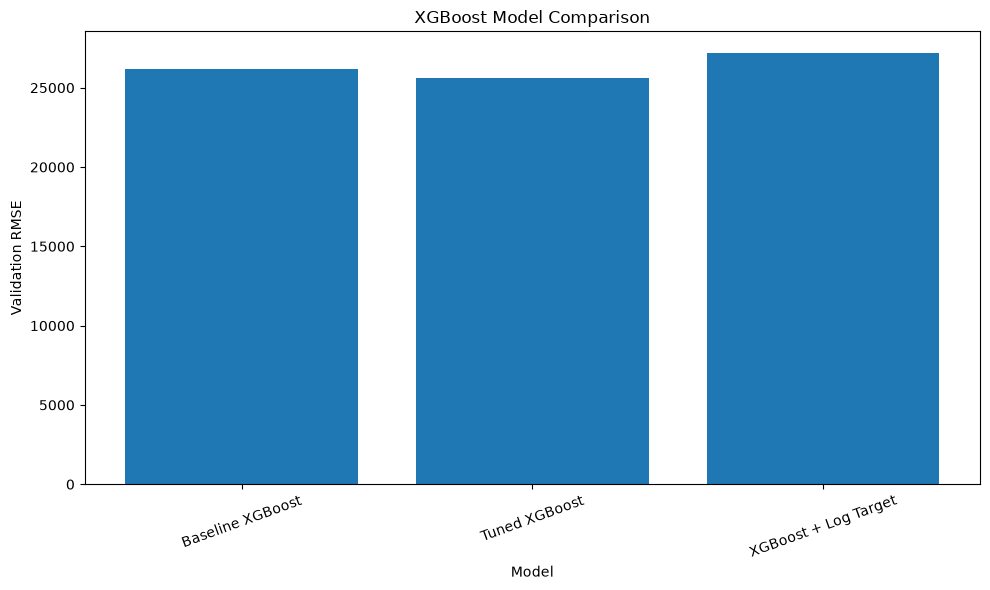

In [55]:
plt.figure(figsize=(10,6))

plt.bar(all_results["Model"],all_results["RMSE"])


plt.title("XGBoost Model Comparison")
plt.xlabel("Model")
plt.ylabel("Validation RMSE")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [57]:
best_pipeline=(
        tuned_xgb
        if tuned_result['RMSE'] <=log_result["RMSE"]
        else log_xgb
        )

xgb_model=best_pipeline.named_steps["model"]
xgb_model

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [60]:
feature_names=(best_pipeline.named_steps["preprocessor"].get_feature_names_out())

feature_names

array(['num__Id', 'num__MSSubClass', 'num__LotFrontage', 'num__LotArea',
       'num__OverallQual', 'num__OverallCond', 'num__YearBuilt',
       'num__YearRemodAdd', 'num__MasVnrArea', 'num__BsmtFinSF1',
       'num__BsmtFinSF2', 'num__BsmtUnfSF', 'num__TotalBsmtSF',
       'num__1stFlrSF', 'num__2ndFlrSF', 'num__LowQualFinSF',
       'num__GrLivArea', 'num__BsmtFullBath', 'num__BsmtHalfBath',
       'num__FullBath', 'num__HalfBath', 'num__BedroomAbvGr',
       'num__KitchenAbvGr', 'num__TotRmsAbvGrd', 'num__Fireplaces',
       'num__GarageYrBlt', 'num__GarageCars', 'num__GarageArea',
       'num__WoodDeckSF', 'num__OpenPorchSF', 'num__EnclosedPorch',
       'num__3SsnPorch', 'num__ScreenPorch', 'num__PoolArea',
       'num__MiscVal', 'num__MoSold', 'num__YrSold',
       'cat__MSZoning_C (all)', 'cat__MSZoning_FV', 'cat__MSZoning_RH',
       'cat__MSZoning_RL', 'cat__MSZoning_RM', 'cat__Street_Grvl',
       'cat__Street_Pave', 'cat__Alley_Grvl', 'cat__Alley_Pave',
       'cat__LotShape

In [61]:
importance=xgb_model.feature_importances_
importance

array([6.3746440e-04, 8.0902764e-04, 1.4193517e-03, 4.3760007e-03,
       1.7732425e-01, 9.9116275e-03, 1.1748746e-02, 6.8005621e-03,
       8.9616457e-04, 5.0811875e-03, 1.2551681e-03, 8.3482376e-04,
       7.8221671e-03, 5.1229354e-03, 4.3402906e-03, 1.4940815e-04,
       2.0904586e-02, 4.1282899e-03, 5.9203390e-05, 7.2044512e-04,
       1.9672427e-03, 3.7964813e-03, 2.8855003e-02, 3.5894790e-03,
       1.8217988e-02, 1.6790966e-03, 5.6511026e-02, 7.0005977e-03,
       1.3226131e-03, 1.6123980e-03, 1.3409718e-03, 6.9827598e-04,
       2.3035449e-03, 0.0000000e+00, 3.2095480e-04, 8.6605921e-04,
       7.6535105e-04, 0.0000000e+00, 1.9844994e-03, 5.0391565e-04,
       1.2816457e-03, 2.9815674e-02, 0.0000000e+00, 0.0000000e+00,
       1.9500554e-03, 5.9803139e-04, 5.7730335e-04, 7.0167467e-04,
       1.0208343e-03, 7.9917622e-04, 6.0884408e-03, 1.6033259e-03,
       0.0000000e+00, 3.3286146e-03, 0.0000000e+00, 0.0000000e+00,
       2.1432077e-03, 3.3131961e-03, 7.1397162e-04, 0.0000000e

In [63]:
feature_importance=pd.DataFrame({
        "Feature":feature_names,
        "Importance":importance
})

feature_importance=feature_importance.sort_values(by='Importance',ascending=False)

feature_importance.head()

,Feature,Importance
4,num__OverallQual,0.177324
169,cat__ExterQual_TA,0.109932
217,cat__CentralAir_Y,0.057211
26,num__GarageCars,0.056511
246,cat__GarageFinish_Unf,0.050558


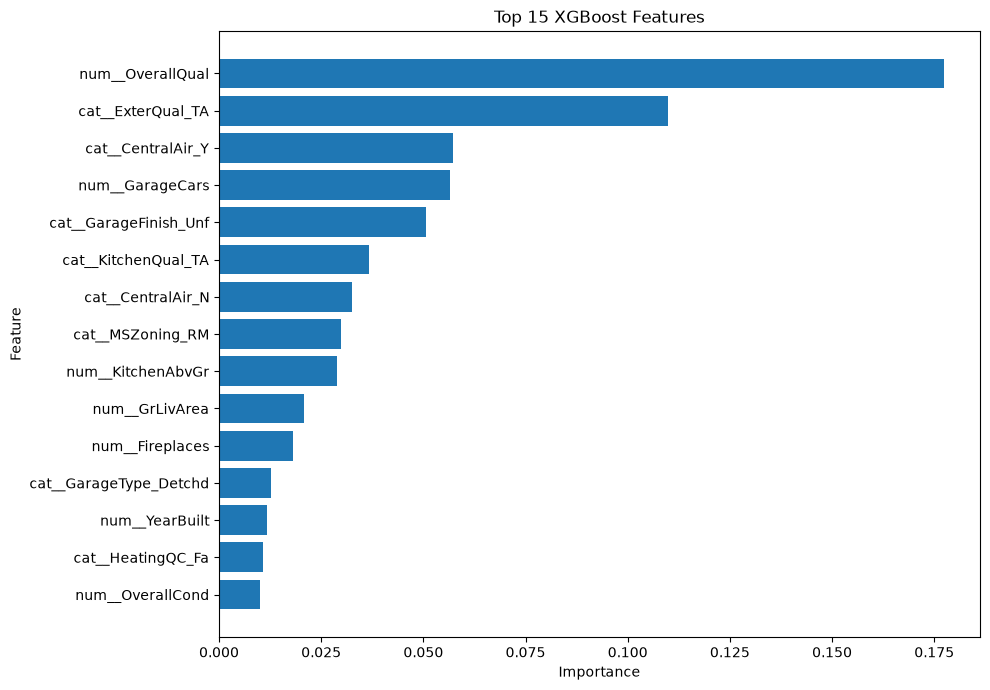

In [68]:
top_features=feature_importance.head(15)

plt.figure(figsize=(10,7))

plt.barh(top_features['Feature'][::-1],
         top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Features")

plt.tight_layout()
plt.show()


In [71]:
best_predictions=(
    tuned_predictions
    if tuned_result["RMSE"] <= log_result["RMSE"]
    else final_predictions
    )

error_df=pd.DataFrame({
    "Actual":y_valid,
    "Predicted":best_predictions
    })

error_df["Error"]=(error_df["Actual"]-error_df["Predicted"])

error_df["Absolute_Error"]=(error_df["Error"].abs())

error_df.sort_values(by="Absolute_Error",ascending=False).head(10)


,Actual,Predicted,Error,Absolute_Error
691,755000,575375.375000,179624.625000,179624.625000
898,611657,475466.062500,136190.937500,136190.937500
581,253293,365462.531250,-112169.531250,112169.531250
774,395000,298098.593750,96901.406250,96901.406250
218,311500,224610.031250,86889.968750,86889.968750
261,276000,359156.968750,-83156.968750,83156.968750
529,200624,278864.812500,-78240.812500,78240.812500
607,225000,156291.671875,68708.328125,68708.328125
588,143000,207999.968750,-64999.968750,64999.968750
1024,287000,348082.562500,-61082.562500,61082.562500


In [72]:
best_result=all_results.loc[all_results["RMSE"].idxmin()]
best_result

Model    Tuned XGBoost
MAE       15780.585938
RMSE       25586.72781
R2            0.914648
Name: 1, dtype: object

In [74]:
print("Best model:", best_result["Model"])
print("MAE:", best_result["MAE"])
print("RMSE:", best_result["RMSE"])
print("R²:", best_result["R2"])

Best model: Tuned XGBoost
MAE: 15780.5859375
RMSE: 25586.72780955001
R²: 0.91464763879776




## In this notebook I improved the baseline XGBoost model.

## Experiments

### 1. Baseline XGBoost

Established the original performance as a benchmark.

### 2. Cross-Validation

Used 5-fold cross-validation to obtain a more reliable estimate
of model performance.

### 3. Hyperparameter Tuning

Used RandomizedSearchCV to search for better XGBoost parameters.

Parameters explored included:

- n_estimators
- learning_rate
- max_depth
- min_child_weight
- subsample
- colsample_bytree

### 4. Log-Transformed Target

Applied:

log(1 + SalePrice)

to reduce the effect of the highly skewed target distribution.

Predictions were converted back using:

exp(prediction) - 1

### 5. Feature Importance

Analyzed the features that contributed most strongly to the
XGBoost predictions.

## Final Model

The model with the lowest validation RMSE was selected as the
current best candidate.
